# Variational autoencoder

https://medium.com/@rekalantar/variational-auto-encoder-vae-pytorch-tutorial-dce2d2fe0f5f

In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from mpl_toolkits.axes_grid1 import ImageGrid

In [2]:
# create a transofrm to apply to each datapoint
transform = transforms.Compose([transforms.ToTensor()])

# download the MNIST datasets
path = '~/datasets'
train_dataset = MNIST(path, transform=transform, download=True)
test_dataset  = MNIST(path, transform=transform, download=True)

# create train and test dataloaders
batch_size = 100
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

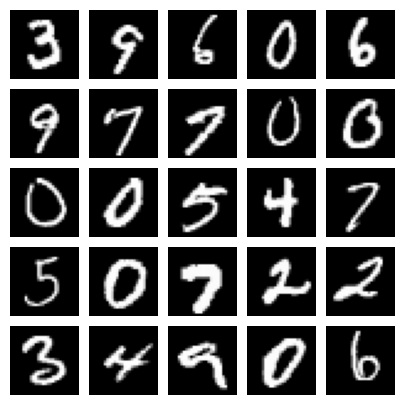

In [3]:
# get 25 sample training images for visualization
dataiter = iter(train_loader)
image = next(dataiter)

num_samples = 25
sample_images = [image[0][i,0] for i in range(num_samples)] 

fig = plt.figure(figsize=(5, 5))
grid = ImageGrid(fig, 111, nrows_ncols=(5, 5), axes_pad=0.1)

for ax, im in zip(grid, sample_images):
    ax.imshow(im, cmap='gray')
    ax.axis('off')

plt.show()

In [4]:
class VAE(nn.Module):

    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=200, device=device):
        super(VAE, self).__init__()

        # encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, latent_dim),
            nn.LeakyReLU(0.2)
            )
        
        # latent mean and variance 
        self.mean_layer = nn.Linear(latent_dim, 2)
        self.logvar_layer = nn.Linear(latent_dim, 2)
        
        # decoder
        self.decoder = nn.Sequential(
            nn.Linear(2, latent_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(latent_dim, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
            )
     
    def encode(self, x):
        x = self.encoder(x)
        return self.mean_layer(x), self.logvar_layer(x)

    def reparameterization(self, mean, std):
        epsilon = torch.randn_like(mean).to(device)      
        z = mean + std*epsilon
        return z

    def decode(self, x):
        return self.decoder(x)

    def forward(self, x):
        mean, log_var = self.encode(x)
        z = self.reparameterization(mean, torch.exp(0.5 * log_var)) 
        x_hat = self.decode(z)  
        return x_hat, mean, log_var

In [5]:
model = VAE().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)

In [6]:
def loss_function(x, x_hat, mean, log_var):
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    KLD = - 0.5 * torch.sum(1+ log_var - mean.pow(2) - log_var.exp())

    return reproduction_loss + KLD

In [7]:
def train(model, optimizer, epochs, device, x_dim=784):
    model.train()
    for epoch in range(epochs):
        overall_loss = 0
        for batch_idx, (x, _) in enumerate(train_loader):
            x = x.view(batch_size, x_dim).to(device)

            optimizer.zero_grad()

            x_hat, mean, log_var = model(x)
            loss = loss_function(x, x_hat, mean, log_var)
            
            overall_loss += loss.item()
            
            loss.backward()
            optimizer.step()

        print("\tEpoch", epoch + 1, "\tAverage Loss: ", overall_loss/(batch_idx*batch_size))
    return overall_loss

In [8]:
train(model, optimizer, epochs=50, device=device)

	Epoch 1 	Average Loss:  181.91079259703673
	Epoch 2 	Average Loss:  162.2845544657763
	Epoch 3 	Average Loss:  158.03609538032137
	Epoch 4 	Average Loss:  155.35714203033703
	Epoch 5 	Average Loss:  153.37954057543823
	Epoch 6 	Average Loss:  151.8949079357523
	Epoch 7 	Average Loss:  150.79067946903695
	Epoch 8 	Average Loss:  149.86115537614774
	Epoch 9 	Average Loss:  149.06951491417988
	Epoch 10 	Average Loss:  148.50954445560308
	Epoch 11 	Average Loss:  148.02103036310518
	Epoch 12 	Average Loss:  147.45657531432596
	Epoch 13 	Average Loss:  147.1013313530363
	Epoch 14 	Average Loss:  146.75130300174771
	Epoch 15 	Average Loss:  146.32304457624687
	Epoch 16 	Average Loss:  146.06083873513148
	Epoch 17 	Average Loss:  145.7946375958629
	Epoch 18 	Average Loss:  145.59129044827316
	Epoch 19 	Average Loss:  145.20572461263563
	Epoch 20 	Average Loss:  144.91267552039858
	Epoch 21 	Average Loss:  144.78398046222873
	Epoch 22 	Average Loss:  144.56675882329924
	Epoch 23 	Average Loss

8418990.392578125

In [9]:
def generate_digit(x1, x2):
    z_sample = torch.tensor([[x1, x2]], dtype=torch.float).to(device)
    x_decoded = model.decode(z_sample)
    digit = x_decoded.detach().cpu().reshape(28, 28) # reshape vector to 2d array
    plt.title(f'[{x1}, {x2}]')
    plt.imshow(digit, cmap='gray')
    plt.axis('off')

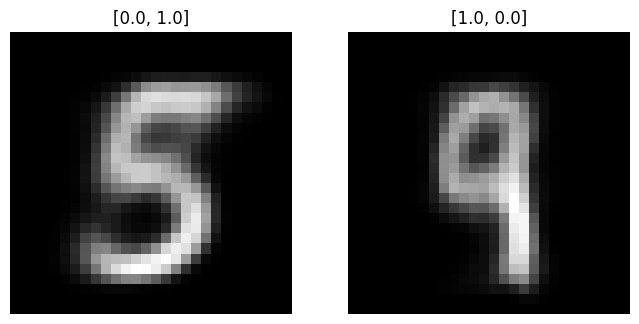

In [10]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
generate_digit(0.0, 1.0)
plt.subplot(1,2,2)
generate_digit(1.0, 0.0)

In [11]:
def plot_latent_space(model, scale=5.0, n=25, digit_size=28, figsize=12):
    # display a n*n 2D manifold of digits
    figure = np.zeros((digit_size * n, digit_size * n))

    # construct a grid 
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float).to(device)
            x_decoded = model.decode(z_sample)
            digit = x_decoded[0].detach().cpu().reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size, j * digit_size : (j + 1) * digit_size,] = digit

    plt.figure(figsize=(figsize, figsize))
    plt.title('VAE Latent Space Visualization')
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("$z_0$")
    plt.ylabel("$z_1$")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

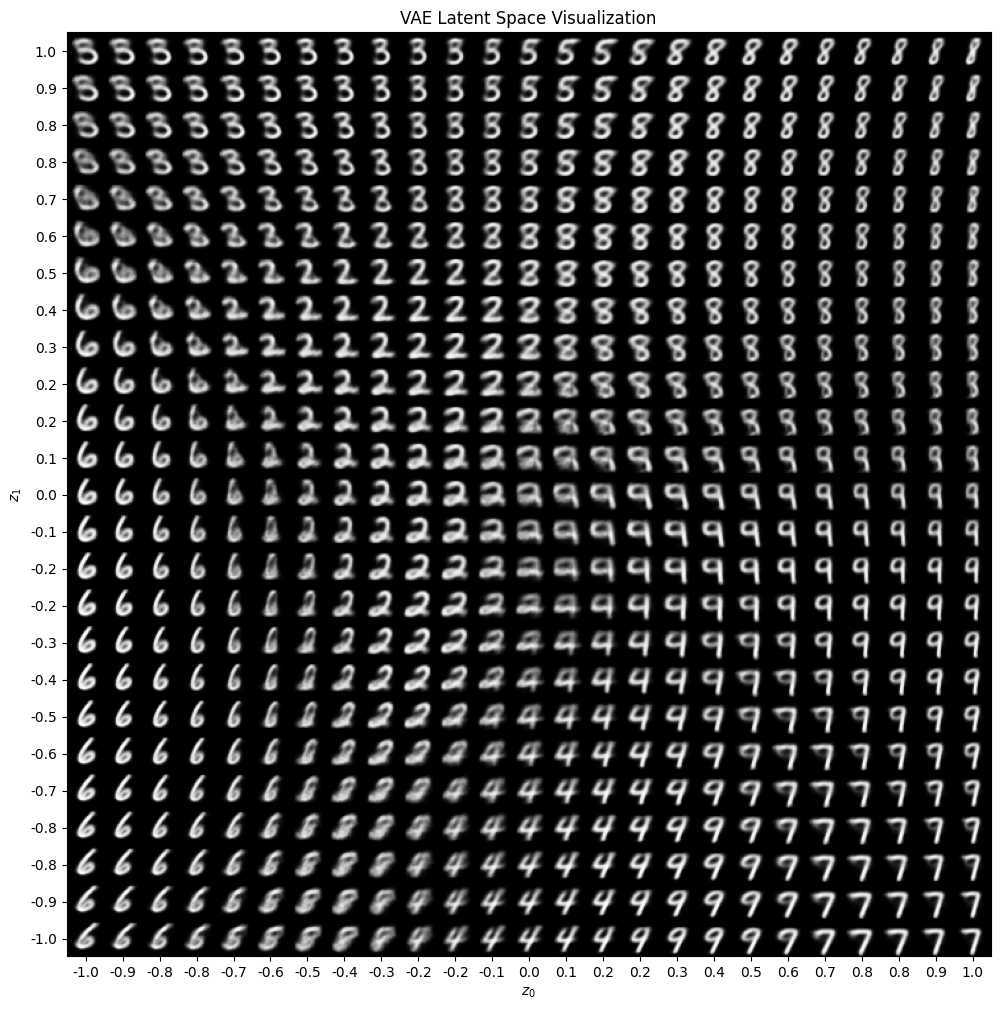

In [12]:
plot_latent_space(model, scale=1.0)

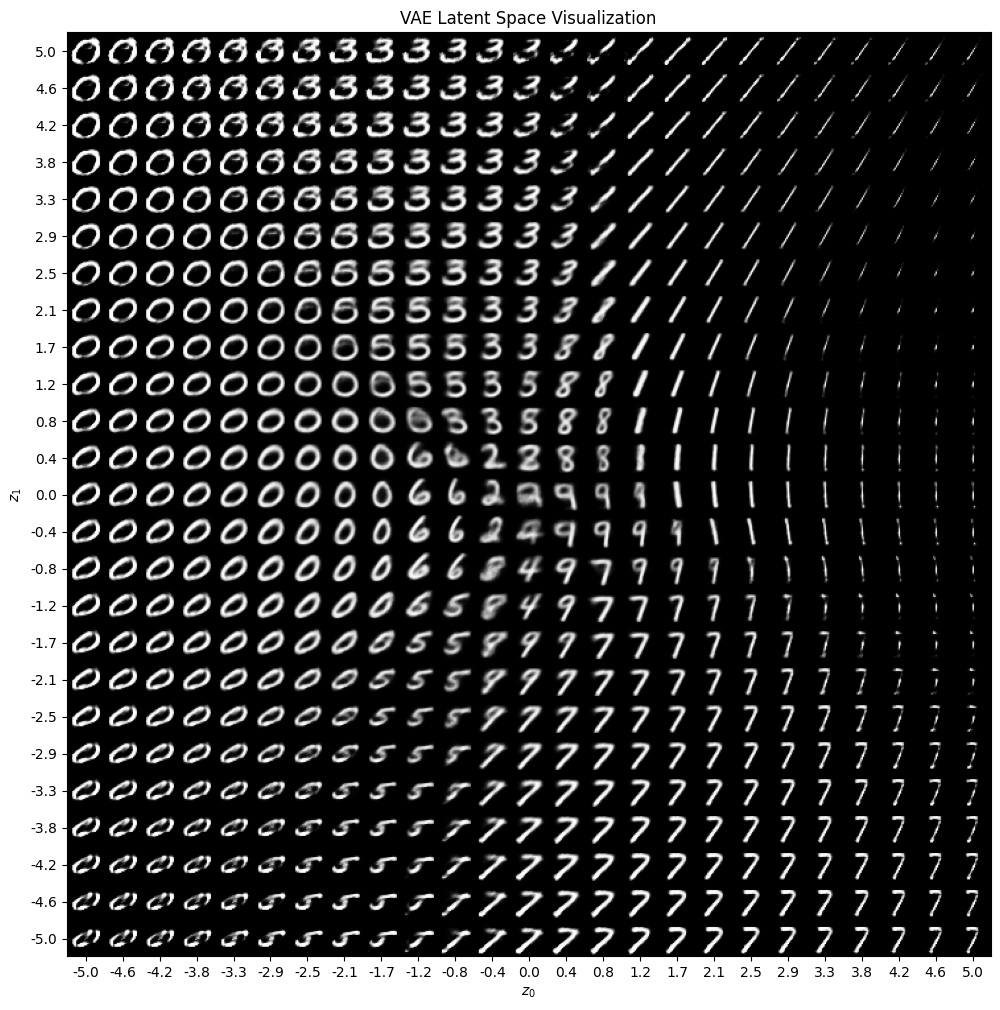

In [13]:
plot_latent_space(model, scale=5.0)

In [14]:
raw = train_dataset.data.numpy().astype(np.float32).reshape(-1,1,28*28)/255

In [15]:
x2d = model.encode(torch.from_numpy(raw).to(device))[0].detach().cpu().numpy().reshape(-1,2)

In [16]:
cl = train_dataset.targets.numpy()

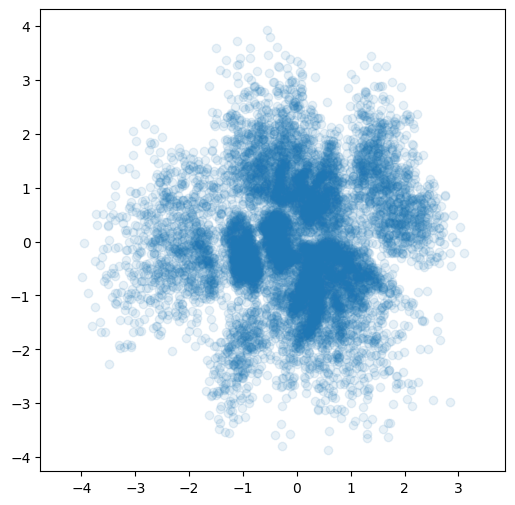

In [17]:
plt.figure(figsize=(6,6))
plt.axis('equal')
plt.scatter(*x2d[:10000].T,alpha=0.1);

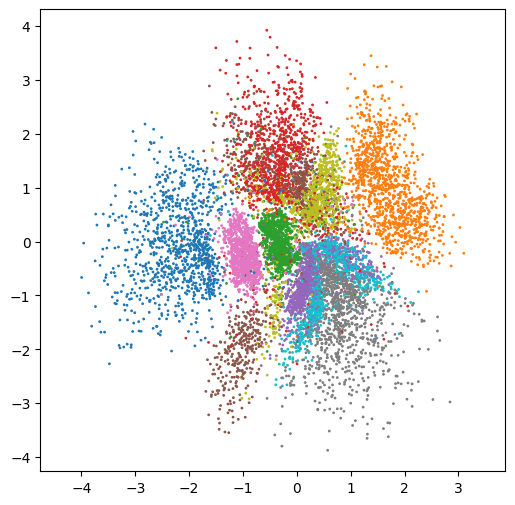

In [18]:
plt.figure(figsize=(6,6))
plt.axis('equal')
plt.scatter(*x2d[:10000].T,s=1,c=cl[:10000],cmap='tab10');

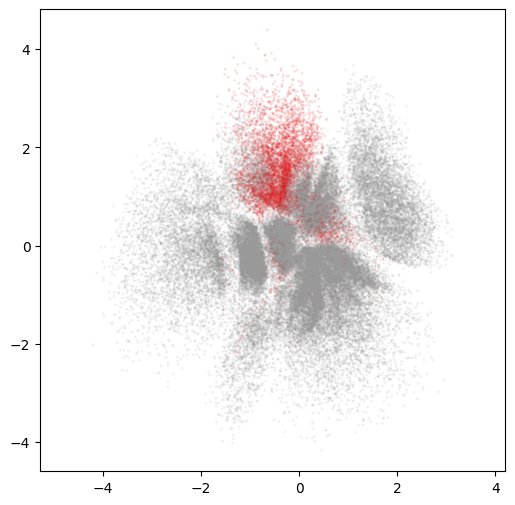

In [19]:
plt.figure(figsize=(6,6))
plt.axis('equal')
plt.scatter(*x2d.T,s=1,c=cl!=3,cmap='Set1',alpha=0.1);